In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
plt.style.use('ggplot')
from matplotlib.pyplot import figure
matplotlib.rcParams['figure.figsize'] = (12,8)
pd.options.mode.chained_assignment = None
%matplotlib inline

In [3]:
import kagglehub, os

path = kagglehub.dataset_download("harshshinde8/movies-csv")
df = pd.read_csv(os.path.join(path, "movies.csv"))
df.head()


100%|██████████| 5.13M/5.13M [00:04<00:00, 1.09MB/s]

Extracting files...


,index,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,cast,crew,director
0,0,237000000,Action Adventure Fantasy Science Fiction,http://www.avatarmovie.com/,19995,culture clash future space war space colony so...,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,Sam Worthington Zoe Saldana Sigourney Weaver S...,"[{'name': 'Stephen E. Rivkin', 'gender': 0, 'd...",James Cameron
1,1,300000000,Adventure Fantasy Action,http://disney.go.com/disneypictures/pirates/,285,ocean drug abuse exotic island east india trad...,en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,Johnny Depp Orlando Bloom Keira Knightley Stel...,"[{'name': 'Dariusz Wolski', 'gender': 2, 'depa...",Gore Verbinski
2,2,245000000,Action Adventure Crime,http://www.sonypictures.com/movies/spectre/,206647,spy based on novel secret agent sequel mi6,en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,...,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,Daniel Craig Christoph Waltz L\u00e9a Seydoux ...,"[{'name': 'Thomas Newman', 'gender': 2, 'depar...",Sam Mendes
3,3,250000000,Action Crime Drama Thriller,http://www.thedarkknightrises.com/,49026,dc comics crime fighter terrorist secret ident...,en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,...,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,Christian Bale Michael Caine Gary Oldman Anne ...,"[{'name': 'Hans Zimmer', 'gender': 2, 'departm...",Christopher Nolan
4,4,260000000,Action Adventure Science Fiction,http://movies.disney.com/john-carter,49529,based on novel mars medallion space travel pri...,en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,...,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,Taylor Kitsch Lynn Collins Samantha Morton Wil...,"[{'name': 'Andrew Stanton', 'gender': 2, 'depa...",Andrew Stanton


In [4]:
for col in df.columns:
    pct_missing = np.mean(df[col].isnull())
    print('{} - {}%'.format(col, round(pct_missing*100)))

index - 0%
budget - 0%
genres - 1%
homepage - 64%
id - 0%
keywords - 9%
original_language - 0%
original_title - 0%
overview - 0%
popularity - 0%
production_companies - 0%
production_countries - 0%
release_date - 0%
revenue - 0%
runtime - 0%
spoken_languages - 0%
status - 0%
tagline - 18%
title - 0%
vote_average - 0%
vote_count - 0%
cast - 1%
crew - 0%
director - 1%


In [6]:
print(df.dtypes)

index                     int64
budget                    int64
genres                   object
homepage                 object
id                        int64
keywords                 object
original_language        object
original_title           object
overview                 object
popularity              float64
production_companies     object
production_countries     object
release_date             object
revenue                   int64
runtime                 float64
spoken_languages         object
status                   object
tagline                  object
title                    object
vote_average            float64
vote_count                int64
cast                     object
crew                     object
director                 object
dtype: object


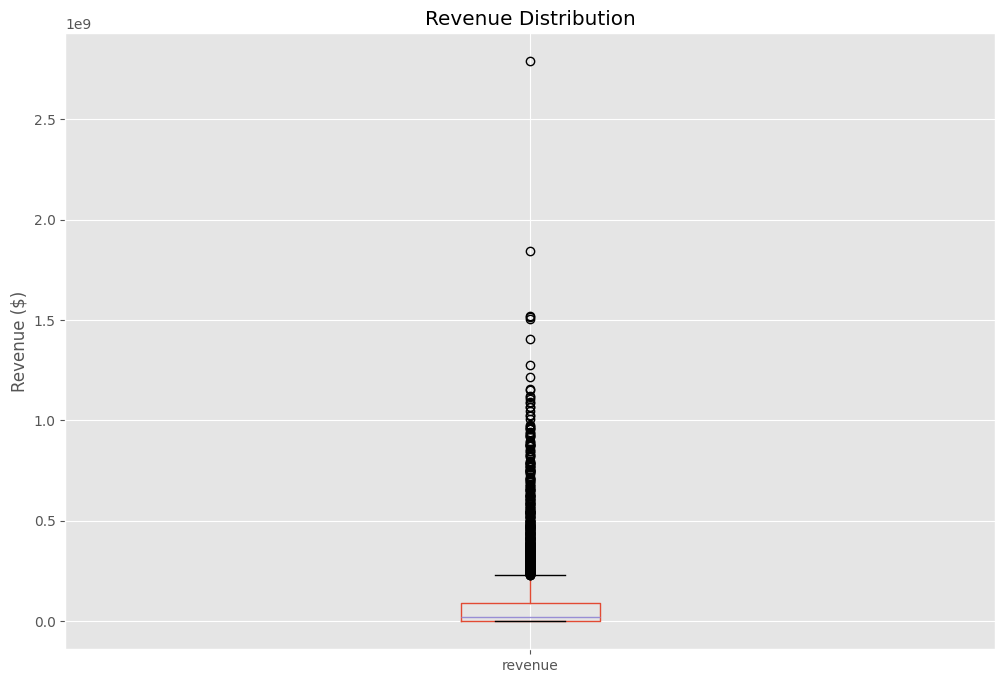

In [9]:
df.boxplot(column=['revenue'])
plt.title("Revenue Distribution")
plt.ylabel("Revenue ($)")
plt.show()

In [20]:
top_10_revenue = df.sort_values(by='revenue', ascending=False, inplace=False)
print(top_10_revenue[['title', 'revenue']].head(10))

                          title     revenue
0                        Avatar  2787965087
25                      Titanic  1845034188
16                 The Avengers  1519557910
28               Jurassic World  1513528810
44                    Furious 7  1506249360
7       Avengers: Age of Ultron  1405403694
124                      Frozen  1274219009
31                   Iron Man 3  1215439994
546                     Minions  1156730962
26   Captain America: Civil War  1153304495


In [21]:
top_10_budget = df.sort_values(by='budget', ascending=False, inplace=False)
print(top_10_budget[['title', 'budget']].head(10))

                                          title     budget
17  Pirates of the Caribbean: On Stranger Tides  380000000
1      Pirates of the Caribbean: At World's End  300000000
7                       Avengers: Age of Ultron  280000000
10                             Superman Returns  270000000
6                                       Tangled  260000000
4                                   John Carter  260000000
5                                  Spider-Man 3  258000000
13                              The Lone Ranger  255000000
46                   X-Men: Days of Future Past  250000000
9            Batman v Superman: Dawn of Justice  250000000


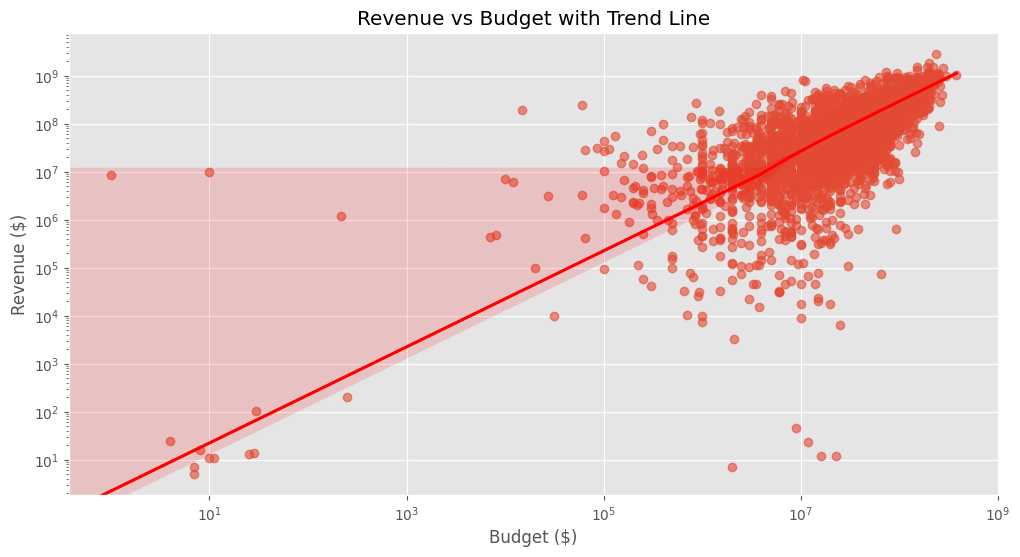

In [23]:
plt.figure(figsize=(12,6))
sns.regplot(x='budget', y='revenue', data=df, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Budget ($)")
plt.ylabel("Revenue ($)")
plt.title("Revenue vs Budget with Trend Line")
plt.show()